# Ce Notebook doit être utilisé sur Colab

# Deep Learning Pipeline — Classification de Radiographies Thoraciques (CXR)

**Objectif** : Classifier des radiographies thoraciques masquées en 4 classes :  
- **COVID** — COVID-19  
- **Lung_Opacity** — Opacité pulmonaire  
- **Normal** — Radiographie normale  
- **Viral Pneumonia** — Pneumonie virale  

**Approche** :  
1. CNN baseline (from scratch)  
2. Transfer Learning avec EfficientNetV2B0  
3. Transfer Learning avec DenseNet121 (architecture CheXNet)  
4. Comparaison des modèles  
5. Interprétabilité (Grad-CAM)  

**Données** : Images masquées 256×256 en niveaux de gris (PNG), redimensionnées à 224×224 pour le modèle.

## 1. Configuration & Imports

In [24]:
from datetime import datetime

start = datetime.now()

In [25]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── Reproductibilité ──
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU ──
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f"TensorFlow {tf.__version__} — GPU {'activé (' + gpus[0].name + ')' if gpus else 'non détecté (CPU)'}")

TensorFlow 2.19.0 — GPU activé (/physical_device:GPU:0)


In [26]:
!pwd

/content


In [27]:
# On monte les données dans content/ (pour Google Colab)

from google.colab import drive
import subprocess
drive.mount('/content/drive')

dataset_archive = '/content/drive/MyDrive/DS_COVID/unmasked_full_dataset_256_256_L.zip'


print("📦 Extraction dataset...")
os.makedirs('./data/processed/', exist_ok=True)
subprocess.run(['unzip', '-o', '-q', dataset_archive, '-d',  './data/processed/'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Extraction dataset...


CompletedProcess(args=['unzip', '-o', '-q', '/content/drive/MyDrive/DS_COVID/unmasked_full_dataset_256_256_L.zip', '-d', './data/processed/'], returncode=0)

In [28]:
! ls data/processed/

unmasked_full_dataset_256_256_L


In [29]:
# ── Constantes ──

print("Working directory : ", Path.cwd())
DATA_DIR = Path("/content/data/processed/unmasked_full_dataset_256_256_L")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Répertoire : {DATA_DIR.resolve()}")
print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")

Working directory :  /content
Répertoire : /content/data/processed/unmasked_full_dataset_256_256_L
Classes (4) : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## 2. Chargement et Exploration des Données

### 2.1 Distribution des classes

  COVID: 3,616 images
  Lung_Opacity: 6,012 images
  Normal: 10,192 images
  Viral Pneumonia: 1,345 images
  ──────────────────
  Total: 21,165 images


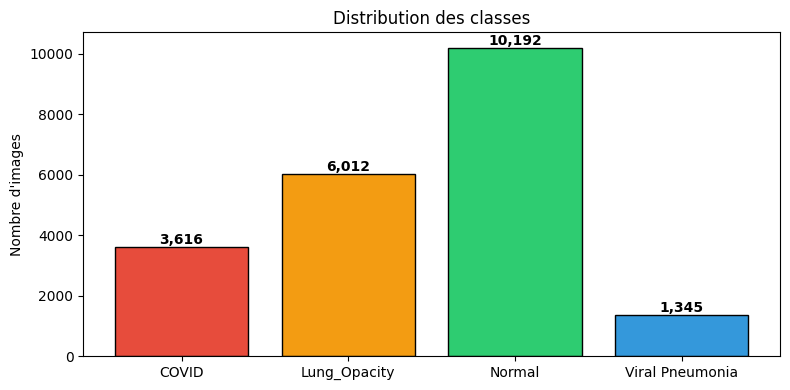


Ratio de déséquilibre max/min : 7.6x (Normal / Viral Pneumonia)


In [30]:
# Compter les images par classe
class_counts = {}
for cls in CLASS_NAMES:
    count = len(list((DATA_DIR / cls).glob("*.png")))
    class_counts[cls] = count
    print(f"  {cls}: {count:,} images")

total = sum(class_counts.values())
print(f"  ──────────────────")
print(f"  Total: {total:,} images")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black')
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{count:,}", ha='center', fontweight='bold')
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes")
plt.tight_layout()
plt.show()

# Déséquilibre
max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
ratio = class_counts[max_cls] / class_counts[min_cls]
print(f"\nRatio de déséquilibre max/min : {ratio:.1f}x ({max_cls} / {min_cls})")

### 2.2 Échantillons visuels

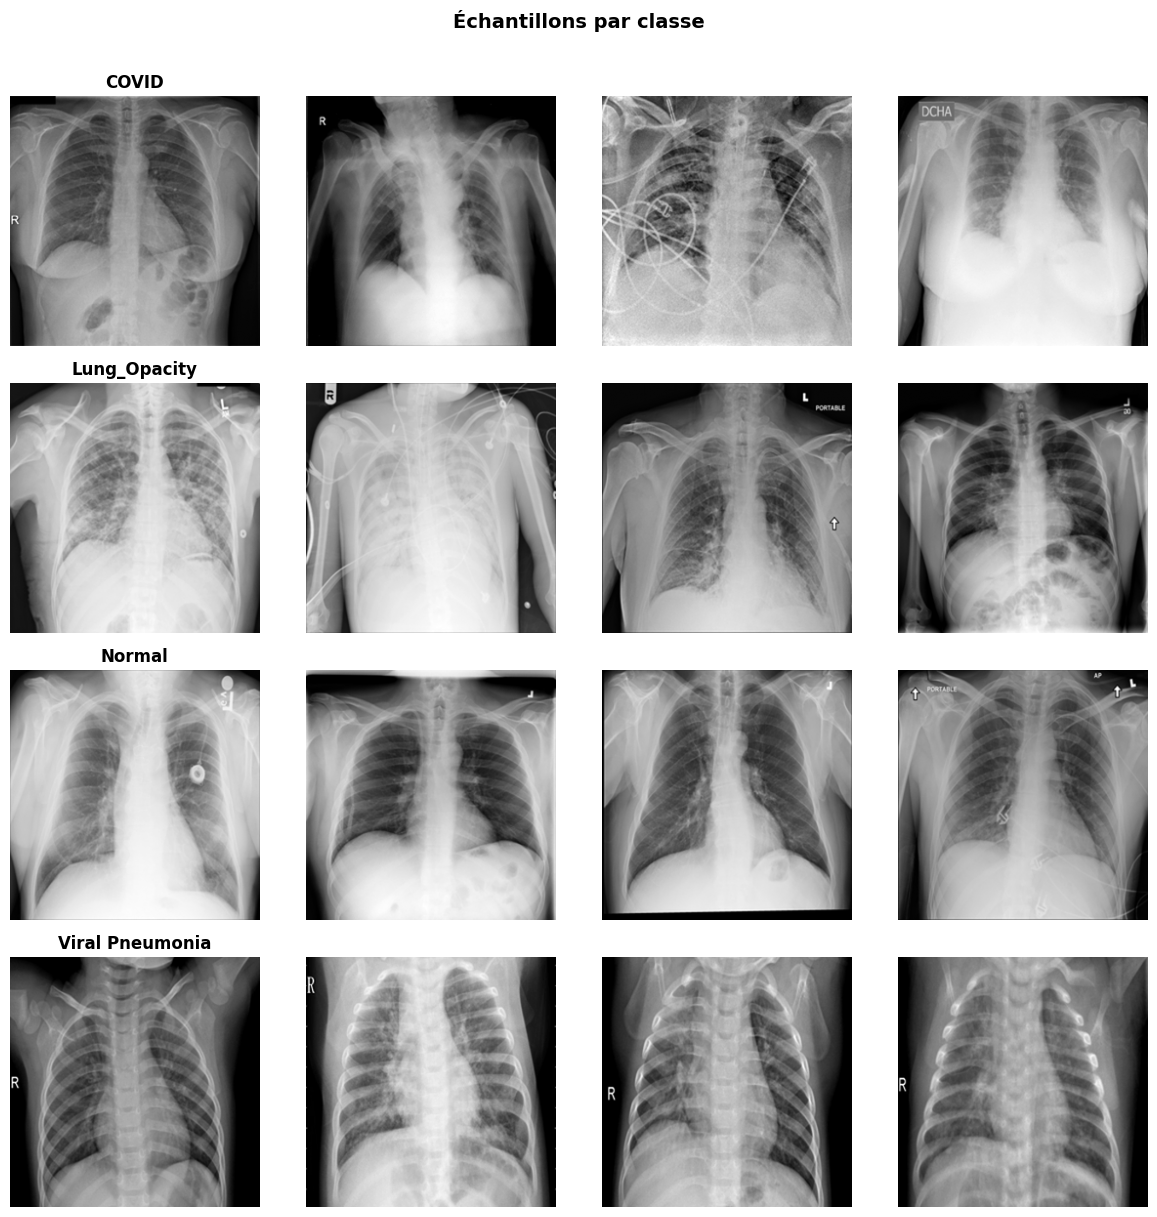

In [31]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3 * NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    images = list((DATA_DIR / cls).glob("*.png"))
    samples = random.sample(images, min(4, len(images)))
    for j, img_path in enumerate(samples):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, fontsize=12, fontweight='bold')

plt.suptitle("Échantillons par classe", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Chargement des datasets (train / val / test)

In [32]:
# Split 70/15/15 via deux appels :
# 1) On extrait 30% (val+test) vs 70% (train)
# 2) On re-split le 30% en 50/50 → 15% val, 15% test

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=True,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=True,
)

# Séparer val_test en val (50%) et test (50%)
val_test_size = tf.data.experimental.cardinality(val_test_ds).numpy() # Nombre total de batches dans val_test
val_size = val_test_size // 2
val_ds = val_test_ds.take(val_size) # Prendre les premiers val_size batches pour la validation
test_ds = val_test_ds.skip(val_size) # Prendre les derniers val_size batches pour le test

print(f"Train : {tf.data.experimental.cardinality(train_ds).numpy()} batches")
print(f"Val   : {tf.data.experimental.cardinality(val_ds).numpy()} batches")
print(f"Test  : {tf.data.experimental.cardinality(test_ds).numpy()} batches")
print(f"Classes : {train_ds.class_names}")

Found 21165 files belonging to 4 classes.
Using 14816 files for training.
Found 21165 files belonging to 4 classes.
Using 6349 files for validation.
Train : 463 batches
Val   : 99 batches
Test  : 100 batches
Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


### 2.4 Prétraitement CLAHE (Contrast Limited Adaptive Histogram Equalization)

**CLAHE** améliore le contraste local des radiographies en égalisant l'histogramme par sous-régions (tuiles), avec une limitation de l'amplification pour éviter le bruit.

Paramètres utilisés :
- `clipLimit=2.0` — limite d'amplification du contraste
- `tileGridSize=(8, 8)` — taille des tuiles d'égalisation adaptative

Cette étape est appliquée **avant** la normalisation [0, 1] et l'augmentation.

In [33]:
def apply_clahe_batch(images, labels):
    """Applique CLAHE sur un batch d'images via tf.py_function."""

    def _clahe_numpy(images_tensor):
        images_np = images_tensor.numpy()
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        result = np.empty_like(images_np)
        for i in range(images_np.shape[0]):
            img = np.squeeze(images_np[i]).astype(np.uint8)
            result[i] = clahe.apply(img)[..., np.newaxis].astype(np.float32)
        return result

    enhanced = tf.py_function(_clahe_numpy, [images], tf.float32)
    enhanced.set_shape(images.shape)
    return enhanced, labels


# Appliquer CLAHE sur les 3 splits
train_ds = train_ds.map(apply_clahe_batch, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(apply_clahe_batch, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(apply_clahe_batch, num_parallel_calls=tf.data.AUTOTUNE)

print("CLAHE appliqué sur train / val / test.")

CLAHE appliqué sur train / val / test.


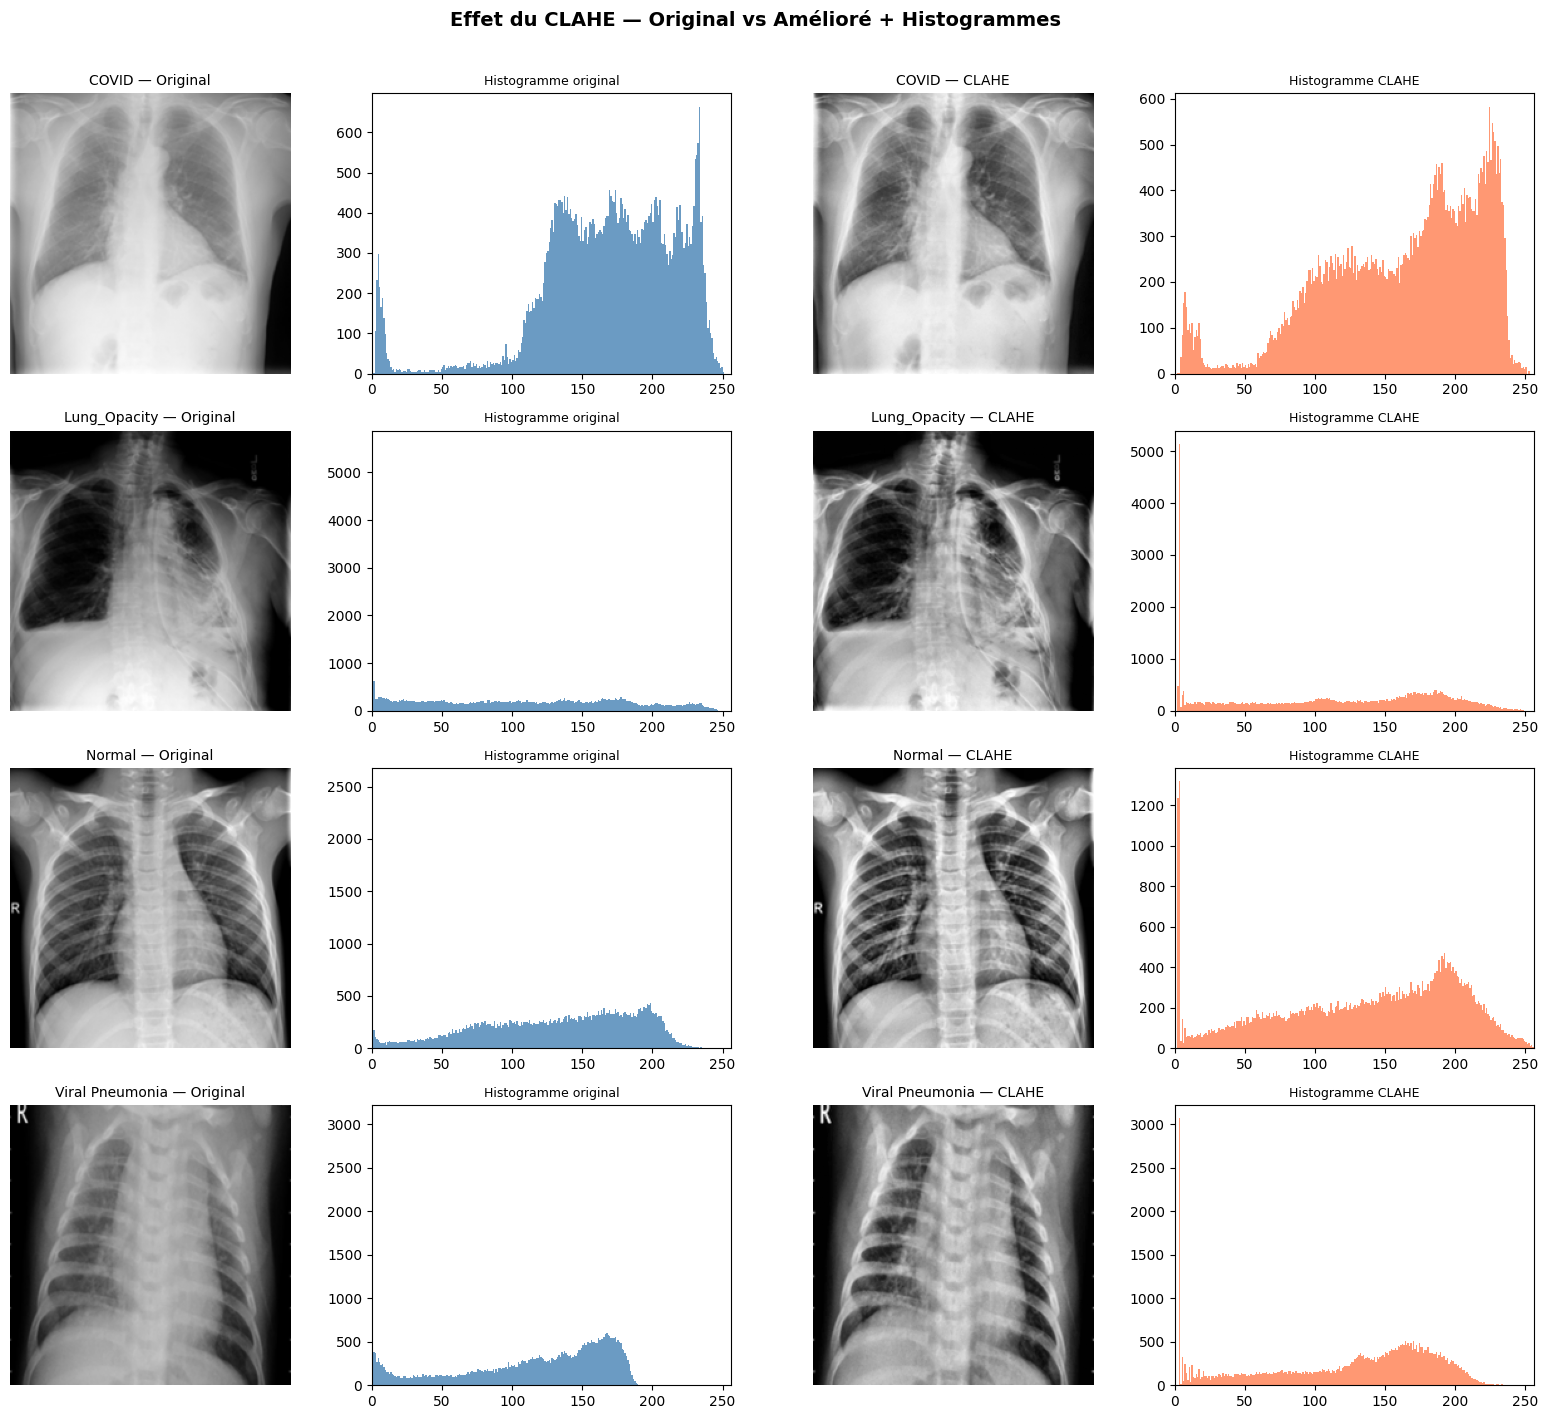

In [34]:
# Visualisation avant / après CLAHE
clahe_preview = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(16, 3.5 * NUM_CLASSES))
fig.suptitle("Effet du CLAHE — Original vs Amélioré + Histogrammes",
             fontsize=14, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    img_path = next((DATA_DIR / cls).glob("*.png"))
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, IMG_SIZE)
    img_clahe = clahe_preview.apply(img_resized)

    axes[i, 0].imshow(img_resized, cmap='gray')
    axes[i, 0].set_title(f"{cls} — Original", fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].hist(img_resized.ravel(), bins=256, range=(0, 256),
                    color='steelblue', alpha=0.8)
    axes[i, 1].set_title("Histogramme original", fontsize=9)
    axes[i, 1].set_xlim(0, 256)

    axes[i, 2].imshow(img_clahe, cmap='gray')
    axes[i, 2].set_title(f"{cls} — CLAHE", fontsize=10)
    axes[i, 2].axis('off')

    axes[i, 3].hist(img_clahe.ravel(), bins=256, range=(0, 256),
                    color='coral', alpha=0.8)
    axes[i, 3].set_title("Histogramme CLAHE", fontsize=9)
    axes[i, 3].set_xlim(0, 256)

plt.tight_layout()
plt.show()

In [35]:
# Normalisation [0, 1] et optimisation du pipeline
normalization = layers.Rescaling(1.0 / 255)

train_ds_norm = train_ds.map(lambda x, y: (normalization(x), y),
                             num_parallel_calls=tf.data.AUTOTUNE)
val_ds_norm = val_ds.map(lambda x, y: (normalization(x), y),
                          num_parallel_calls=tf.data.AUTOTUNE)
test_ds_norm = test_ds.map(lambda x, y: (normalization(x), y),
                            num_parallel_calls=tf.data.AUTOTUNE)

# Cache + prefetch pour de meilleures performances
train_ds_norm = train_ds_norm.cache().prefetch(tf.data.AUTOTUNE)
val_ds_norm = val_ds_norm.cache().prefetch(tf.data.AUTOTUNE)
test_ds_norm = test_ds_norm.cache().prefetch(tf.data.AUTOTUNE)

# Vérification d'un batch
for images, labels in train_ds_norm.take(1):
    print(f"Batch images : {images.shape}, dtype={images.dtype}")
    print(f"Batch labels : {labels.shape}")
    print(f"Pixel range  : [{images.numpy().min():.3f}, {images.numpy().max():.3f}]")

Batch images : (32, 224, 224, 1), dtype=<dtype: 'float32'>
Batch labels : (32, 4)
Pixel range  : [0.004, 1.000]


In [36]:
# ── Calcul des poids de classes pour compenser le déséquilibre ──
from sklearn.utils.class_weight import compute_class_weight

# Extraire tous les labels du train set
train_labels = []
for _, labels in train_ds:
    train_labels.append(np.argmax(labels.numpy(), axis=1))
train_labels = np.concatenate(train_labels)

# Poids inversement proportionnels à la fréquence
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight = dict(enumerate(weights))

print("Poids des classes (pour compenser le déséquilibre) :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {class_weight[i]:.4f}")


Poids des classes (pour compenser le déséquilibre) :
  COVID: 1.4646
  Lung_Opacity: 0.8754
  Normal: 0.5191
  Viral Pneumonia: 4.0217


## 3. Augmentation des Données

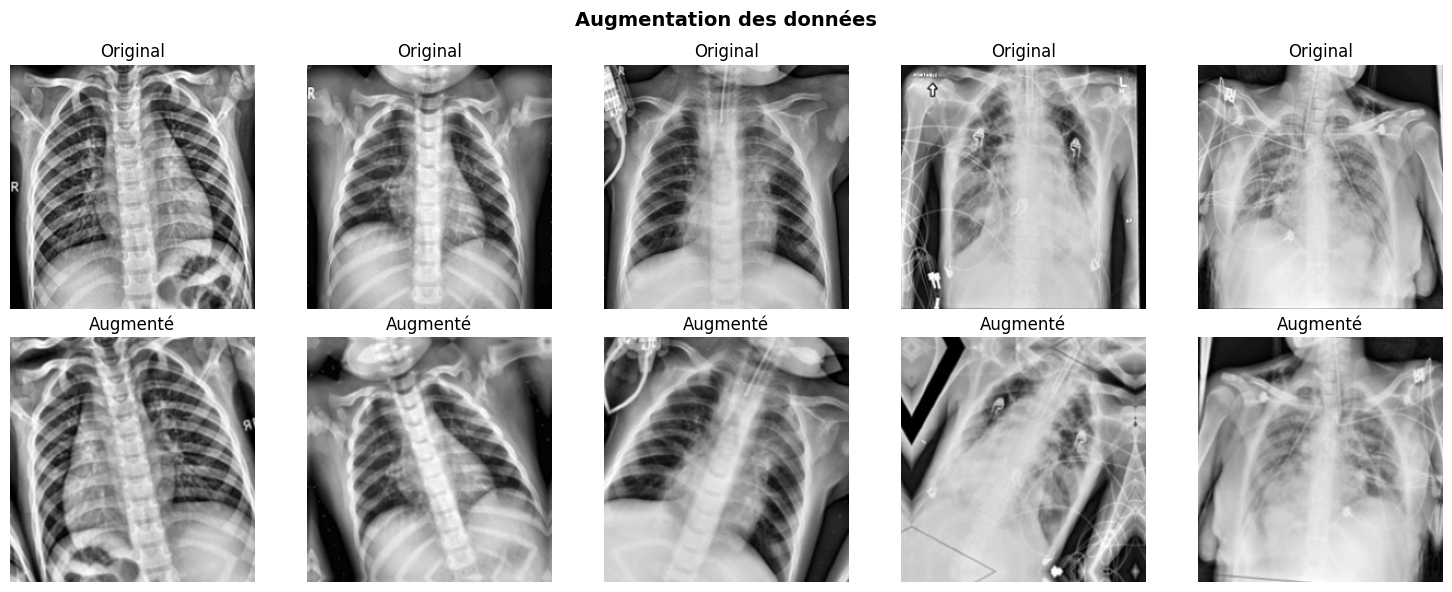

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Visualisation : original vs augmenté
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for images, _ in train_ds_norm.take(1):
    for i in range(5):
        img = images[i]
        axes[0, i].imshow(img.numpy().squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        augmented = data_augmentation(tf.expand_dims(img, 0), training=True)
        axes[1, i].imshow(augmented[0].numpy().squeeze(), cmap='gray')
        axes[1, i].set_title("Augmenté")
        axes[1, i].axis('off')

plt.suptitle("Augmentation des données", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Modèle Baseline : CNN from Scratch

Architecture simple pour établir un plancher de performance :  
4 blocs convolutifs (32 → 64 → 128 → 256 filtres) avec BatchNorm + MaxPool,  
suivi d'un GlobalAveragePooling et d'une tête de classification Dense.

In [38]:
def build_baseline_cnn(input_shape=(224, 224, 1), num_classes=4):
    """CNN baseline avec 4 blocs convolutifs."""
    inputs = layers.Input(shape=input_shape)

    # Augmentation (uniquement en entraînement)
    x = data_augmentation(inputs)

    # Blocs convolutifs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    # Tête de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='baseline_cnn')

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 456,580 (1.74 MB)

 Trainable params: 455,620 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [39]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_baseline = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', patience=5,
        factor=0.5, min_lr=1e-7, verbose=1
    ),
]

print("Entraînement du CNN baseline (avec class_weight)...")
history_baseline = baseline_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=50,
    callbacks=callbacks_baseline,
    class_weight=class_weight,
)

Entraînement du CNN baseline (avec class_weight)...
Epoch 1/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 169ms/step - accuracy: 0.5572 - loss: 0.9973 - val_accuracy: 0.2866 - val_loss: 1.3790 - learning_rate: 0.0010
Epoch 2/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - accuracy: 0.6677 - loss: 0.7304 - val_accuracy: 0.3987 - val_loss: 2.5660 - learning_rate: 0.0010
Epoch 3/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - accuracy: 0.7225 - loss: 0.6139 - val_accuracy: 0.2326 - val_loss: 3.5061 - learning_rate: 0.0010
Epoch 4/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.7502 - loss: 0.5441 - val_accuracy: 0.5281 - val_loss: 1.5473 - learning_rate: 0.0010
Epoch 5/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 65s 141ms/step - accuracy: 0.7642 - loss: 0.5140 - val_accuracy: 0.4151 - val_loss: 1.5357 - learning_rate: 0.0010
Epoch 6/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7759 - loss: 0.4834
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
463/463 ━

### 4.1 Courbes d'entraînement — Baseline CNN

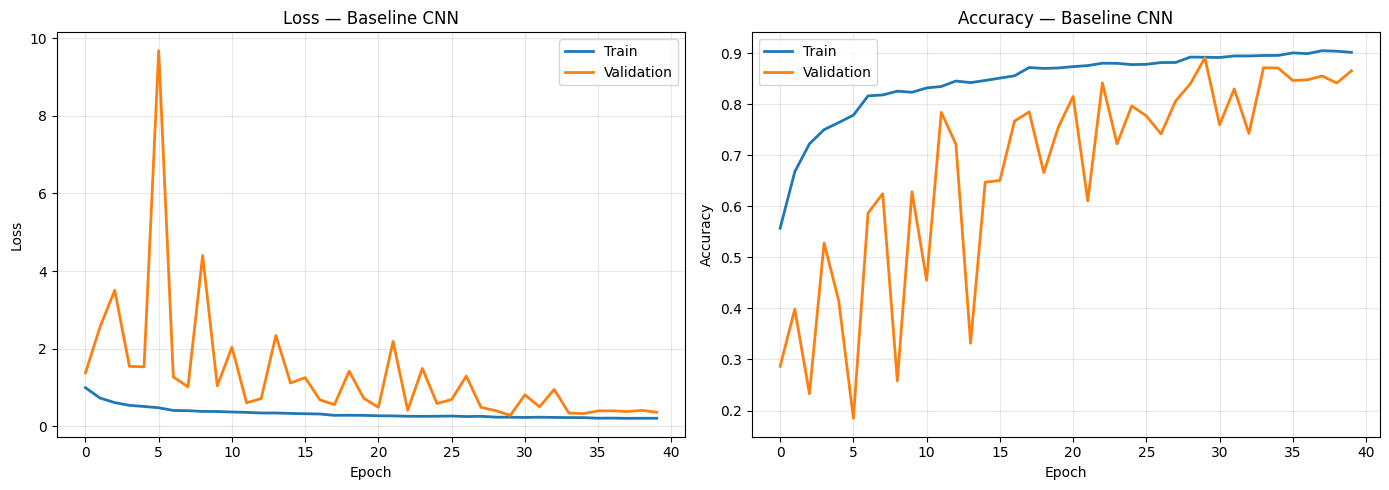

In [40]:
def plot_training_curves(history, title=""):
    """Affiche les courbes loss et accuracy (train vs val)."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history.history['loss'], label='Train', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax1.set_title(f'Loss — {title}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax2.set_title(f'Accuracy — {title}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_baseline, title="Baseline CNN")

### 4.2 Évaluation sur le jeu de test — Baseline CNN


  Évaluation : Baseline CNN
                 precision    recall  f1-score   support

          COVID     0.9693    0.7859    0.8680       523
   Lung_Opacity     0.8829    0.8193    0.8499       902
         Normal     0.8565    0.9502    0.9009      1526
Viral Pneumonia     0.9031    0.8913    0.8972       230

       accuracy                         0.8818      3181
      macro avg     0.9030    0.8617    0.8790      3181
   weighted avg     0.8859    0.8818    0.8808      3181



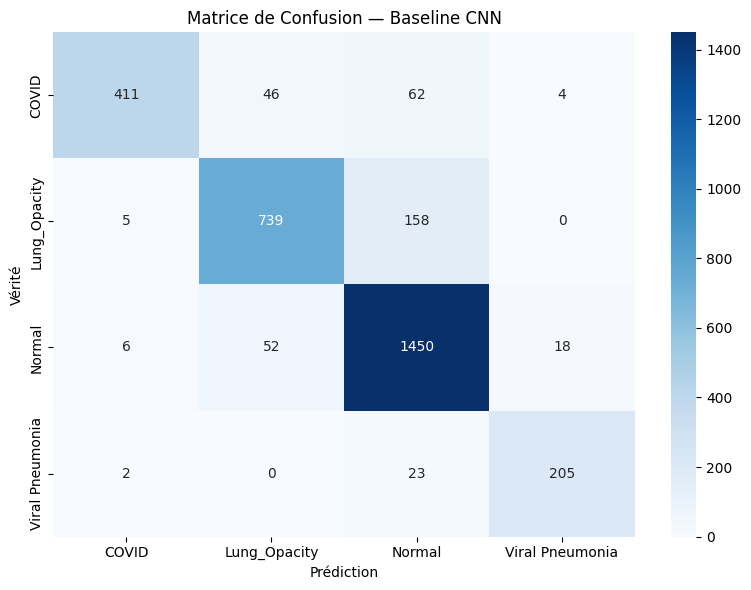

In [41]:
def evaluate_model(model, test_dataset, class_names, model_name=""):
    """Évalue un modèle : classification report + matrice de confusion."""
    # Prédictions
    y_true, y_pred_proba = [], []
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        y_pred_proba.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred_proba = np.concatenate(y_pred_proba)
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred_proba, axis=1)

    # Classification report
    print(f"\n{'='*60}")
    print(f"  Évaluation : {model_name}")
    print(f"{'='*60}")
    report = classification_report(
        y_true_labels, y_pred_labels,
        target_names=class_names, digits=4
    )
    print(report)

    # Matrice de confusion
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vérité')
    ax.set_title(f'Matrice de Confusion — {model_name}')
    plt.tight_layout()
    plt.show()

    return y_true_labels, y_pred_labels, y_pred_proba

y_true_bl, y_pred_bl, y_proba_bl = evaluate_model(
    baseline_model, test_ds_norm, CLASS_NAMES, "Baseline CNN"
)

## 5. Transfer Learning : EfficientNetV2B0

Approche en deux phases :  
1. **Feature Extraction** — Base gelée, seule la tête est entraînée  
2. **Fine-tuning** — Dégel des 30 dernières couches de la base, entraînement à faible learning rate

In [42]:
def build_efficientnet_model(input_shape=(224, 224, 1), num_classes=4):
    """EfficientNetV2B0 avec conversion grayscale → 3 canaux.
    
    Corrections vs v1 :
    - Conversion grayscale→RGB par concaténation (tf.repeat) au lieu de Conv2D(1,1)
    - Application du preprocessing spécifique EfficientNet sur les 3 canaux
    - Tête plus large (512) avec BatchNorm
    """
    # Base pré-entraînée
    base_model = keras.applications.EfficientNetV2B0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False  # Phase 1 : gelé

    # Construction du modèle
    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Conversion 1 canal → 3 canaux par simple réplication
    # (les poids ImageNet attendent 3 canaux corrélés — mieux que Conv2D appris)
    x = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1), name='grayscale_to_rgb')(x)

    # Rescaler [0,1] → [0,255] pour le preprocessing EfficientNet
    x = layers.Rescaling(255.0, name='rescale_to_255')(x)

    # Backbone (le preprocessing interne d'EfficientNetV2 attend [0,255])
    x = base_model(x, training=False)

    # Tête de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='efficientnet_transfer')
    return model, base_model

eff_model, base_model = build_efficientnet_model()
print(f"Couches totales du modèle : {len(eff_model.layers)}")
print(f"Couches de la base EfficientNet : {len(base_model.layers)}")
print(f"Paramètres entraînables : {eff_model.count_params():,}")

eff_model.summary(show_trainable=True)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Couches totales du modèle : 11
Couches de la base EfficientNet : 270
Paramètres entraînables : 6,582,356


Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5 (InputLayer)  │ (None, 224, 224, 1)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ data_augmentation           │ (None, 224, 224, 1)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ grayscale_to_rgb (Lambda)   │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescale_to_255 (Rescaling)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetv2-b0           │ (None, 7, 7, 1280)    │  5,919,312 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_2  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_8       │ (None, 1280)          │      5,120 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 512)           │    655,872 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 4)             │      2,052 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 6,582,356 (25.11 MB)

 Trainable params: 660,484 (2.52 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

### 5.1 Phase 1 — Feature Extraction (base gelée)

In [43]:
eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_eff_p1 = [
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', patience=3,
        factor=0.5, min_lr=1e-7, verbose=1
    ),
]

print("Phase 1 : Feature Extraction (base gelée, avec class_weight)...")
history_eff_p1 = eff_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=20,
    callbacks=callbacks_eff_p1,
    class_weight=class_weight,
)

Phase 1 : Feature Extraction (base gelée, avec class_weight)...
Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7079 - loss: 0.7919 - val_accuracy: 0.7380 - val_loss: 0.6732 - learning_rate: 0.0010
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.7652 - loss: 0.5189 - val_accuracy: 0.7831 - val_loss: 0.6110 - learning_rate: 0.0010
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.7775 - loss: 0.4786 - val_accuracy: 0.7850 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.7831 - loss: 0.4573 - val_accuracy: 0.7945 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.7921 - loss: 0.4377 - val_accuracy: 0.7844 - val_loss: 0.5188 - learning_rate: 0.0010
Epoch 6/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - accuracy: 0.7999 - loss: 0.4263 - val_accuracy: 0.8318 - val_loss: 0.4366 - learning_rate: 0.0010
Epoch 7/20
4

### 5.2 Phase 2 — Fine-tuning (dégel des 30 dernières couches)

In [44]:
# Dégeler les 30 dernières couches de la base
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Couches dégelées dans la base : {trainable_count} / {len(base_model.layers)}")

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_eff_p2 = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', patience=5,
        factor=0.5, min_lr=1e-8, verbose=1
    ),
]

print("Phase 2 : Fine-tuning (avec class_weight)...")
history_eff_p2 = eff_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=30,
    callbacks=callbacks_eff_p2,
    class_weight=class_weight,
)

Couches dégelées dans la base : 30 / 270
Phase 2 : Fine-tuning (avec class_weight)...
Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8011 - loss: 0.4186 - val_accuracy: 0.8475 - val_loss: 0.4197 - learning_rate: 1.0000e-05
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.8187 - loss: 0.3798 - val_accuracy: 0.8545 - val_loss: 0.3975 - learning_rate: 1.0000e-05
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8258 - loss: 0.3661 - val_accuracy: 0.8526 - val_loss: 0.3921 - learning_rate: 1.0000e-05
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.8297 - loss: 0.3578 - val_accuracy: 0.8608 - val_loss: 0.3816 - learning_rate: 1.0000e-05
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8320 - loss: 0.3517 - val_accuracy: 0.8485 - val_loss: 0.3990 - learning_rate: 1.0000e-05
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8348 - loss: 0.3409 - val_accuracy: 0.8589 - val_loss: 0

### 5.3 Courbes d'entraînement — EfficientNetV2B0 (phases combinées)

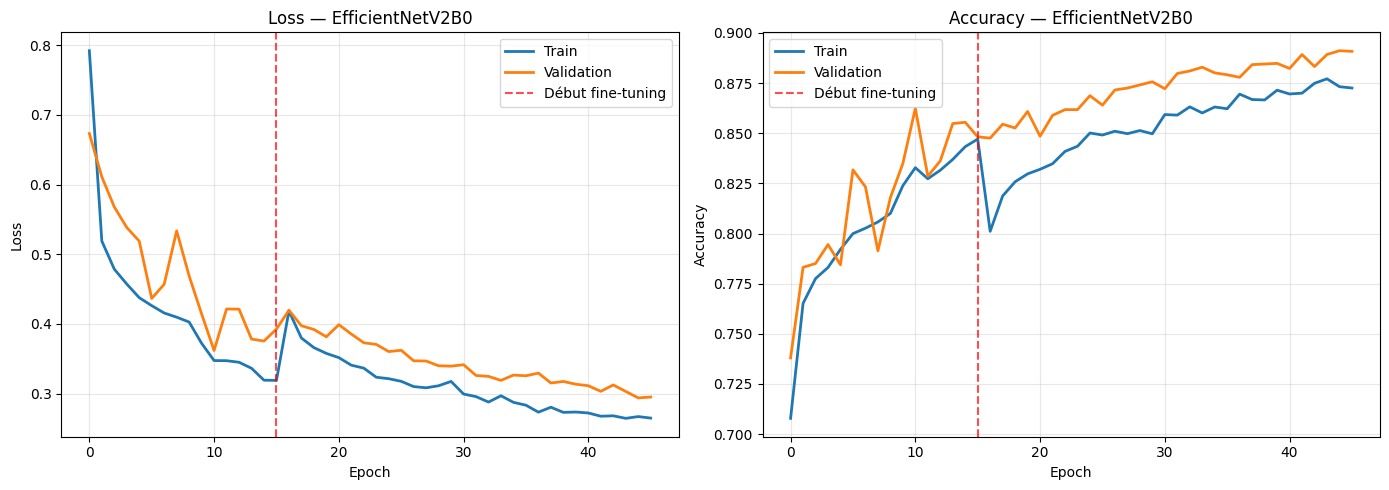

In [45]:
def merge_histories(h1, h2):
    """Fusionne deux historiques Keras."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    class MergedHistory:
        pass
    mh = MergedHistory()
    mh.history = merged
    return mh

history_eff = merge_histories(history_eff_p1, history_eff_p2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
p1_epochs = len(history_eff_p1.history['loss'])

for ax, metric, label in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(history_eff.history[metric], label='Train', linewidth=2)
    ax.plot(history_eff.history[f'val_{metric}'], label='Validation', linewidth=2)
    ax.axvline(x=p1_epochs - 1, color='red', linestyle='--', alpha=0.7, label='Début fine-tuning')
    ax.set_title(f'{label} — EfficientNetV2B0')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Évaluation sur le jeu de test — EfficientNetV2B0


  Évaluation : EfficientNetV2B0
                 precision    recall  f1-score   support

          COVID     0.8354    0.9025    0.8676       523
   Lung_Opacity     0.8754    0.8647    0.8701       902
         Normal     0.9197    0.8702    0.8943      1526
Viral Pneumonia     0.8078    0.9870    0.8885       230

       accuracy                         0.8824      3181
      macro avg     0.8596    0.9061    0.8801      3181
   weighted avg     0.8852    0.8824    0.8826      3181



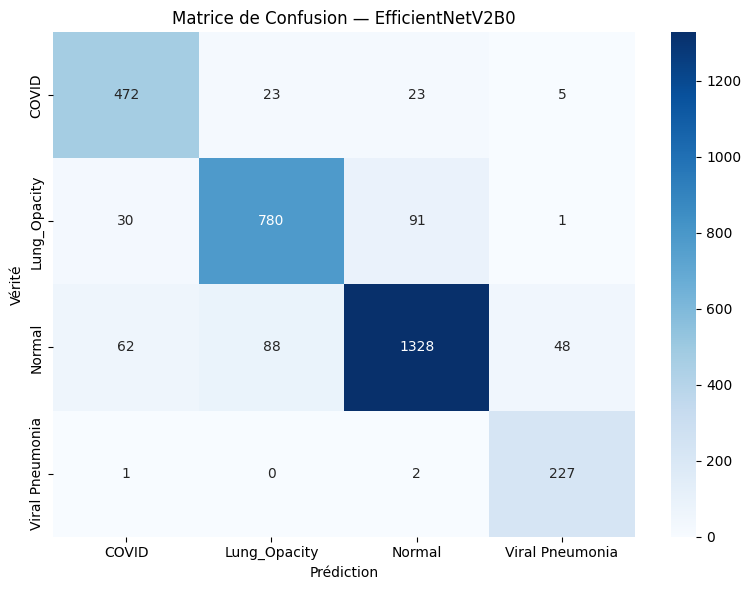

In [46]:
y_true_eff, y_pred_eff, y_proba_eff = evaluate_model(
    eff_model, test_ds_norm, CLASS_NAMES, "EfficientNetV2B0"
)

## 6. Transfer Learning : DenseNet121 (Architecture CheXNet)

**CheXNet** (Rajpurajan et al., Stanford, 2017) utilise un **DenseNet-121** entraîné sur 112 000 radiographies thoraciques.  
L'architecture DenseNet est particulièrement adaptée à l'imagerie médicale grâce à ses **connexions denses** :  
chaque couche reçoit les feature maps de toutes les couches précédentes, préservant les détails subtils.

Ici, on utilise DenseNet121 avec les **poids ImageNet** (l'architecture CheXNet sans ses poids PyTorch),  
car le preprocessing DenseNet (normalisation ImageNet) est standard et bien adapté.

Même approche en deux phases que pour EfficientNet :  
1. **Feature Extraction** — Base gelée  
2. **Fine-tuning** — Dégel des 30 dernières couches

In [47]:
def build_densenet_model(input_shape=(224, 224, 1), num_classes=4):
    """DenseNet121 (architecture CheXNet) avec conversion grayscale → 3 canaux.
    
    DenseNet121 utilise la normalisation ImageNet standard :
    - Entrée attendue en [0, 255] RGB
    - Preprocessing interne : normalisation par canal (mean/std ImageNet)
    
    Les connexions denses propagent les features de toutes les couches
    précédentes, ce qui préserve les détails subtils des radiographies.
    """
    # Base pré-entraînée
    base_model = keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False  # Phase 1 : gelé

    # Construction du modèle
    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Conversion 1 canal → 3 canaux par réplication
    x = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1), name='dn_grayscale_to_rgb')(x)

    # Rescaler [0,1] → [0,255] pour le preprocessing DenseNet
    x = layers.Rescaling(255.0, name='dn_rescale_to_255')(x)

    # Preprocessing DenseNet (normalisation ImageNet par canal)
    x = keras.applications.densenet.preprocess_input(x)

    # Backbone
    x = base_model(x, training=False)

    # Tête de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='densenet121_chexnet')
    return model, base_model

dn_model, dn_base_model = build_densenet_model()
print(f"Couches totales du modèle : {len(dn_model.layers)}")
print(f"Couches de la base DenseNet121 : {len(dn_base_model.layers)}")
print(f"Paramètres entraînables : {sum(p.numpy().size for p in dn_model.trainable_weights):,}")

dn_model.summary(show_trainable=True)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Couches totales du modèle : 11
Couches de la base DenseNet121 : 427
Paramètres entraînables : 528,900


Model: "densenet121_chexnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_7 (InputLayer)  │ (None, 224, 224, 1)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ data_augmentation           │ (None, 224, 224, 1)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dn_grayscale_to_rgb         │ (None, 224, 224, 3)   │          0 │   -   │
│ (Lambda)                    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dn_rescale_to_255           │ (None, 224, 224, 3)   │          0 │   -   │
│ (Rescaling)                 │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ true_divide (TrueDivide)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ add (Add)                   │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ true_divide_1 (TrueDivide)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ densenet121 (Functional)    │ (None, 7, 7, 1024)    │  7,037,504 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_3  │ (None, 1024)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_9       │ (None, 1024)          │      4,096 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_4 (Dropout)         │ (None, 1024)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_6 (Dense)             │ (None, 512)           │    524,800 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_5 (Dropout)         │ (None, 512)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 4)             │      2,052 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 7,568,452 (28.87 MB)

 Trainable params: 528,900 (2.02 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

### 6.1 Phase 1 — Feature Extraction (base gelée)

In [48]:
dn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_dn_p1 = [
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', patience=3,
        factor=0.5, min_lr=1e-7, verbose=1
    ),
]

print("Phase 1 : Feature Extraction DenseNet121 (base gelée, avec class_weight)...")
history_dn_p1 = dn_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=20,
    callbacks=callbacks_dn_p1,
    class_weight=class_weight,
)

Phase 1 : Feature Extraction DenseNet121 (base gelée, avec class_weight)...
Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 102s 187ms/step - accuracy: 0.7347 - loss: 0.6156 - val_accuracy: 0.8068 - val_loss: 0.4877 - learning_rate: 0.0010
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 178ms/step - accuracy: 0.7901 - loss: 0.4534 - val_accuracy: 0.8213 - val_loss: 0.4642 - learning_rate: 0.0010
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.8076 - loss: 0.4086 - val_accuracy: 0.8384 - val_loss: 0.4260 - learning_rate: 0.0010
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 81s 176ms/step - accuracy: 0.8185 - loss: 0.3910 - val_accuracy: 0.8261 - val_loss: 0.4434 - learning_rate: 0.0010
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.8249 - loss: 0.3753 - val_accuracy: 0.8447 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 6/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.8266 - loss: 0.3616 - val_accuracy: 0.8602 - val_loss: 0.3683 - learning_rate: 

### 6.2 Phase 2 — Fine-tuning (dégel des 30 dernières couches)

In [49]:
# Dégeler les 30 dernières couches de la base DenseNet
dn_base_model.trainable = True
fine_tune_from_dn = len(dn_base_model.layers) - 30
for layer in dn_base_model.layers[:fine_tune_from_dn]:
    layer.trainable = False

trainable_count_dn = sum(1 for l in dn_base_model.layers if l.trainable)
print(f"Couches dégelées dans la base DenseNet : {trainable_count_dn} / {len(dn_base_model.layers)}")

dn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_dn_p2 = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', patience=5,
        factor=0.5, min_lr=1e-8, verbose=1
    ),
]

print("Phase 2 : Fine-tuning DenseNet121 (avec class_weight)...")
history_dn_p2 = dn_model.fit(
    train_ds_norm,
    validation_data=val_ds_norm,
    epochs=30,
    callbacks=callbacks_dn_p2,
    class_weight=class_weight,
)

Couches dégelées dans la base DenseNet : 30 / 427
Phase 2 : Fine-tuning DenseNet121 (avec class_weight)...
Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 109s 198ms/step - accuracy: 0.8512 - loss: 0.2950 - val_accuracy: 0.8763 - val_loss: 0.3300 - learning_rate: 1.0000e-05
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 87s 188ms/step - accuracy: 0.8624 - loss: 0.2881 - val_accuracy: 0.8747 - val_loss: 0.3288 - learning_rate: 1.0000e-05
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 87s 187ms/step - accuracy: 0.8651 - loss: 0.2894 - val_accuracy: 0.8747 - val_loss: 0.3308 - learning_rate: 1.0000e-05
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 86s 187ms/step - accuracy: 0.8677 - loss: 0.2762 - val_accuracy: 0.8725 - val_loss: 0.3336 - learning_rate: 1.0000e-05
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 87s 187ms/step - accuracy: 0.8653 - loss: 0.2858 - val_accuracy: 0.8731 - val_loss: 0.3341 - learning_rate: 1.0000e-05
Epoch 6/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 87s 187ms/step - accuracy: 0.8651 - loss: 0.2818 - val_ac

### 6.3 Courbes d'entraînement — DenseNet121 (phases combinées)

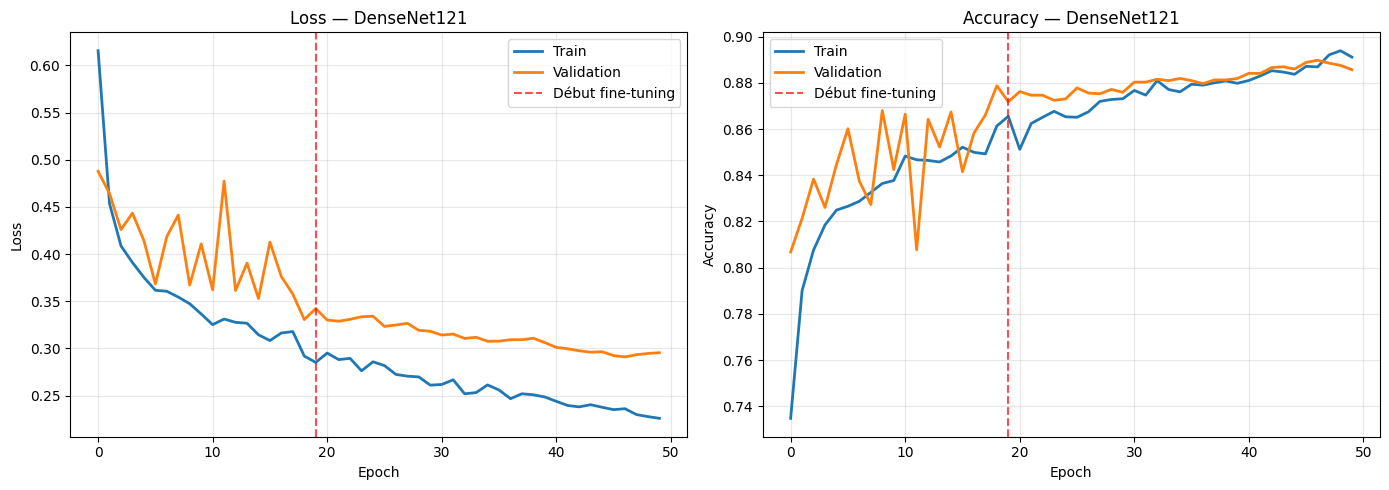

In [50]:
history_dn = merge_histories(history_dn_p1, history_dn_p2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
p1_epochs_dn = len(history_dn_p1.history['loss'])

for ax, metric, label in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(history_dn.history[metric], label='Train', linewidth=2)
    ax.plot(history_dn.history[f'val_{metric}'], label='Validation', linewidth=2)
    ax.axvline(x=p1_epochs_dn - 1, color='red', linestyle='--', alpha=0.7, label='Début fine-tuning')
    ax.set_title(f'{label} — DenseNet121')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Évaluation sur le jeu de test — DenseNet121


  Évaluation : DenseNet121 (CheXNet)
                 precision    recall  f1-score   support

          COVID     0.8462    0.9044    0.8743       523
   Lung_Opacity     0.9159    0.8326    0.8722       902
         Normal     0.9008    0.9227    0.9116      1526
Viral Pneumonia     0.9414    0.9783    0.9595       230

       accuracy                         0.8981      3181
      macro avg     0.9011    0.9095    0.9044      3181
   weighted avg     0.8990    0.8981    0.8978      3181



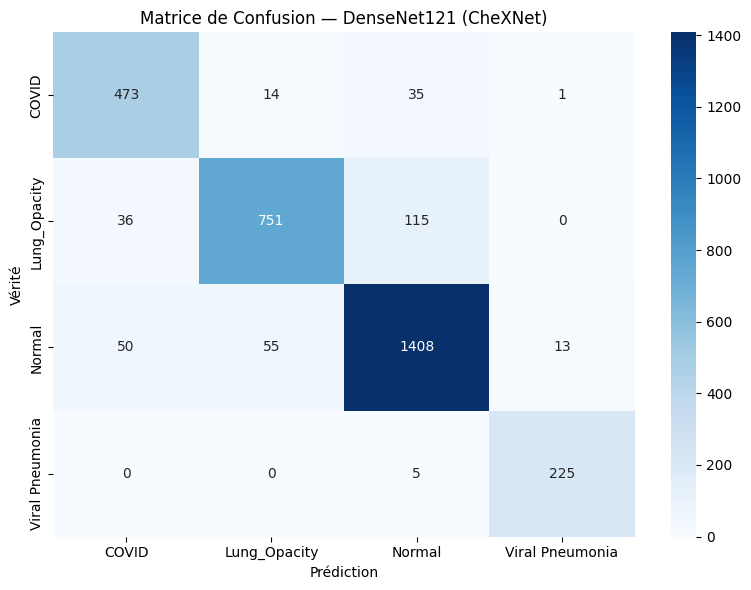

In [51]:
y_true_dn, y_pred_dn, y_proba_dn = evaluate_model(
    dn_model, test_ds_norm, CLASS_NAMES, "DenseNet121 (CheXNet)"
)

## 7. Comparaison des Modèles

                      Baseline CNN  EfficientNetV2B0  DenseNet121
Accuracy                    0.8818            0.8824       0.8981
Precision (weighted)        0.8859            0.8852       0.8990
Recall (weighted)           0.8818            0.8824       0.8981
F1 (weighted)               0.8808            0.8826       0.8978


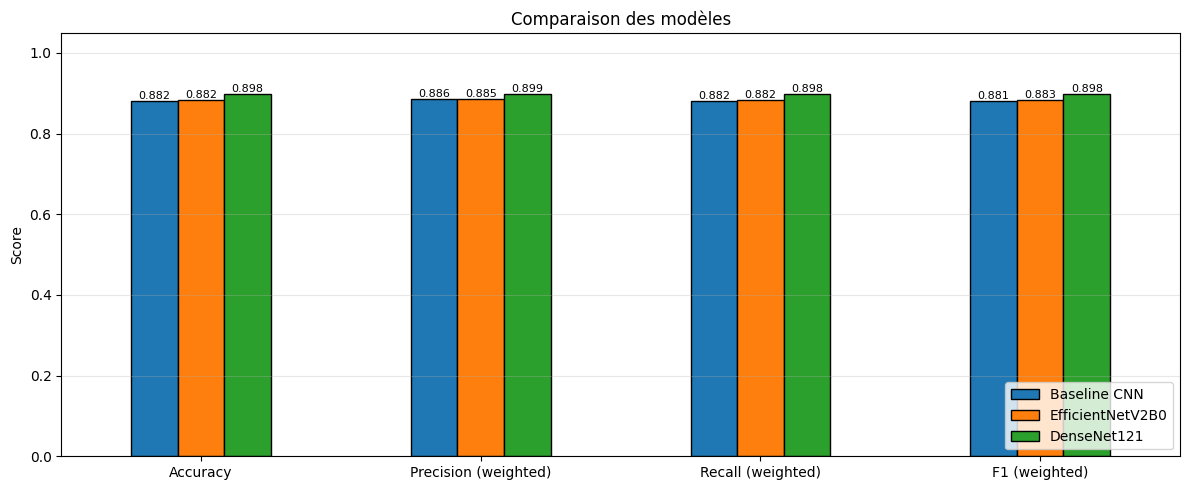

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted'),
    }

metrics_baseline = get_metrics(y_true_bl, y_pred_bl)
metrics_eff = get_metrics(y_true_eff, y_pred_eff)
metrics_dn = get_metrics(y_true_dn, y_pred_dn)

comparison_df = pd.DataFrame({
    'Baseline CNN': metrics_baseline,
    'EfficientNetV2B0': metrics_eff,
    'DenseNet121': metrics_dn,
})
print(comparison_df.round(4).to_string())

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Courbes ROC (One-vs-Rest)

Évaluation fine du meilleur modèle via les courbes ROC par classe.

Meilleur modèle : DenseNet121 (F1 = 0.8978)


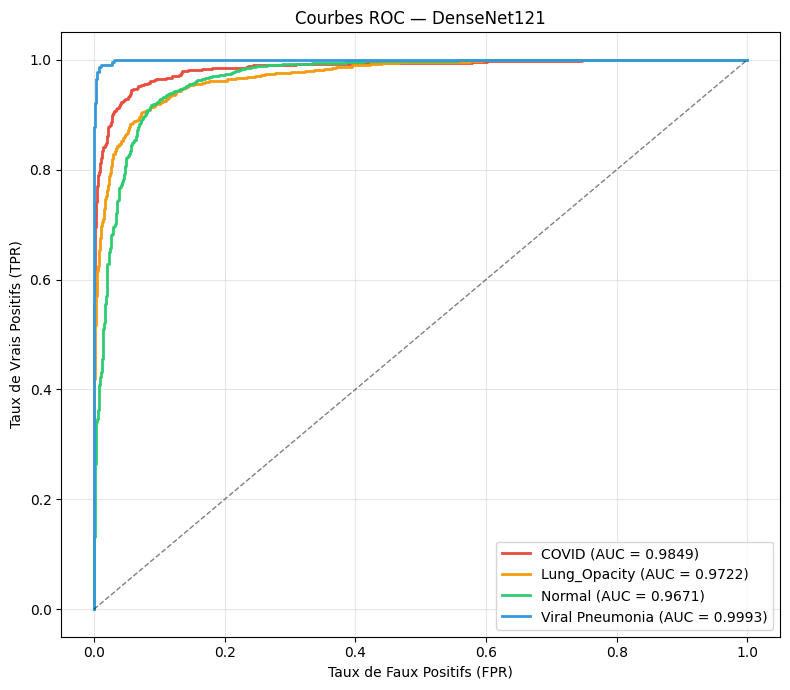

In [53]:
# Sélection du meilleur modèle parmi les 3
all_models = {
    'Baseline CNN': (baseline_model, metrics_baseline, y_true_bl, y_proba_bl),
    'EfficientNetV2B0': (eff_model, metrics_eff, y_true_eff, y_proba_eff),
    'DenseNet121': (dn_model, metrics_dn, y_true_dn, y_proba_dn),
}

best_name = max(all_models, key=lambda k: all_models[k][1]['F1 (weighted)'])
best_model, _, y_true_best, y_proba_best = all_models[best_name]

print(f"Meilleur modèle : {best_name} (F1 = {all_models[best_name][1]['F1 (weighted)']:.4f})")

# Binariser les labels pour ROC one-vs-rest
y_true_bin = label_binarize(y_true_best, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title(f'Courbes ROC — {best_name}')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
end = datetime.now()
print(f"Durée totale : {end - start}")

Durée totale : 2:29:30.729426


## 9. Interprétabilité : Grad-CAM

Visualisation des zones activées par le modèle pour comprendre ses décisions.  
Grad-CAM calcule les gradients de la classe prédite par rapport aux feature maps de la dernière couche convolutive.

In [55]:
def find_last_conv_layer(model):
    """Trouve la dernière couche convolutive du modèle (y compris dans les sous-modèles)."""
    last_conv = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            # Parcourir les sous-modèles (ex: EfficientNet)
            for sub_layer in layer.layers:
                if isinstance(sub_layer, layers.Conv2D):
                    last_conv = (layer.name, sub_layer.name)
        elif isinstance(layer, layers.Conv2D):
            last_conv = (None, layer.name)
    return last_conv


def make_gradcam_heatmap(model, img_array, last_conv_info):
    """Génère une heatmap Grad-CAM."""
    sub_model_name, conv_layer_name = last_conv_info

    if sub_model_name:
        # Pour les modèles avec sous-modèle (Transfer Learning)
        sub_model = model.get_layer(sub_model_name)
        grad_model = Model(
            inputs=model.input,
            outputs=[
                sub_model.get_layer(conv_layer_name).output,
                model.output
            ]
        )
    else:
        # Pour les modèles simples (CNN from scratch)
        grad_model = Model(
            inputs=model.input,
            outputs=[
                model.get_layer(conv_layer_name).output,
                model.output
            ]
        )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        class_output = predictions[:, pred_class]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_class.numpy()


def overlay_gradcam(img, heatmap, alpha=0.5):
    """Superpose la heatmap Grad-CAM sur l'image avec meilleur contraste."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Normaliser l'image pour un meilleur contraste (CLAHE-like)
    img_squeezed = img.squeeze()
    if img_squeezed.max() > 0:
        img_norm = (img_squeezed - img_squeezed.min()) / (img_squeezed.max() - img_squeezed.min() + 1e-8)
    else:
        img_norm = img_squeezed
    img_rgb = np.uint8(255 * np.stack([img_norm] * 3, axis=-1))

    overlay = cv2.addWeighted(img_rgb, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay


last_conv_info = find_last_conv_layer(best_model)
print(f"Dernière couche convolutive : {last_conv_info}")


Dernière couche convolutive : ('densenet121', 'conv5_block16_2_conv')


In [56]:
# Collecter des exemples de prédictions correctes et incorrectes
correct_examples = {cls: [] for cls in CLASS_NAMES}
incorrect_examples = {cls: [] for cls in CLASS_NAMES}

for images, labels in test_ds_norm:
    preds = best_model.predict(images, verbose=0)
    for i in range(len(images)):
        true_label = np.argmax(labels[i].numpy())
        pred_label = np.argmax(preds[i])
        cls = CLASS_NAMES[true_label]

        if true_label == pred_label and len(correct_examples[cls]) < 3:
            correct_examples[cls].append(images[i].numpy())
        elif true_label != pred_label and len(incorrect_examples[cls]) < 3:
            incorrect_examples[cls].append(
                (images[i].numpy(), CLASS_NAMES[pred_label])
            )

print("Exemples collectés :")
for cls in CLASS_NAMES:
    print(f"  {cls}: {len(correct_examples[cls])} corrects, {len(incorrect_examples[cls])} incorrects")

Exemples collectés :
  COVID: 3 corrects, 3 incorrects
  Lung_Opacity: 3 corrects, 3 incorrects
  Normal: 3 corrects, 3 incorrects
  Viral Pneumonia: 3 corrects, 3 incorrects


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m135977323969472\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[0.10588236],\n         [0.08235294],\n         [0.07843138],\n         ...,\n         [0.30980393],\n         [0.33333334],\n         [0.3803922 ]],\n\n        [[0.07843138],\n         [0.0627451 ],\n         [0.05490196],\n         ...,\n         [0.2784314 ],\n         [0.30980393],\n         [0.34901962]],\n\n        [[0.05490196],\n         [0.04313726],\n         [0.04313726],\n         ...,\n         [0.27058825],\n         [0.3019608 ],\n         [0.34117648]],\n\n        ...,\n\n        [[0.6666667 ],\n         [0.7176471 ],\n         [0.7803922 ],\n         ...,\n         [0.22352943],\n         [0.21568629],\n         [0.20392159]],\n\n        [[0.6745098 ],\n         [0.7294118 ],\n         [0.8078432 ],\n         ...,\n         [0.21568629],\n         [0.23529413],\n         [0.24313727]],\n\n        [[0.69411767

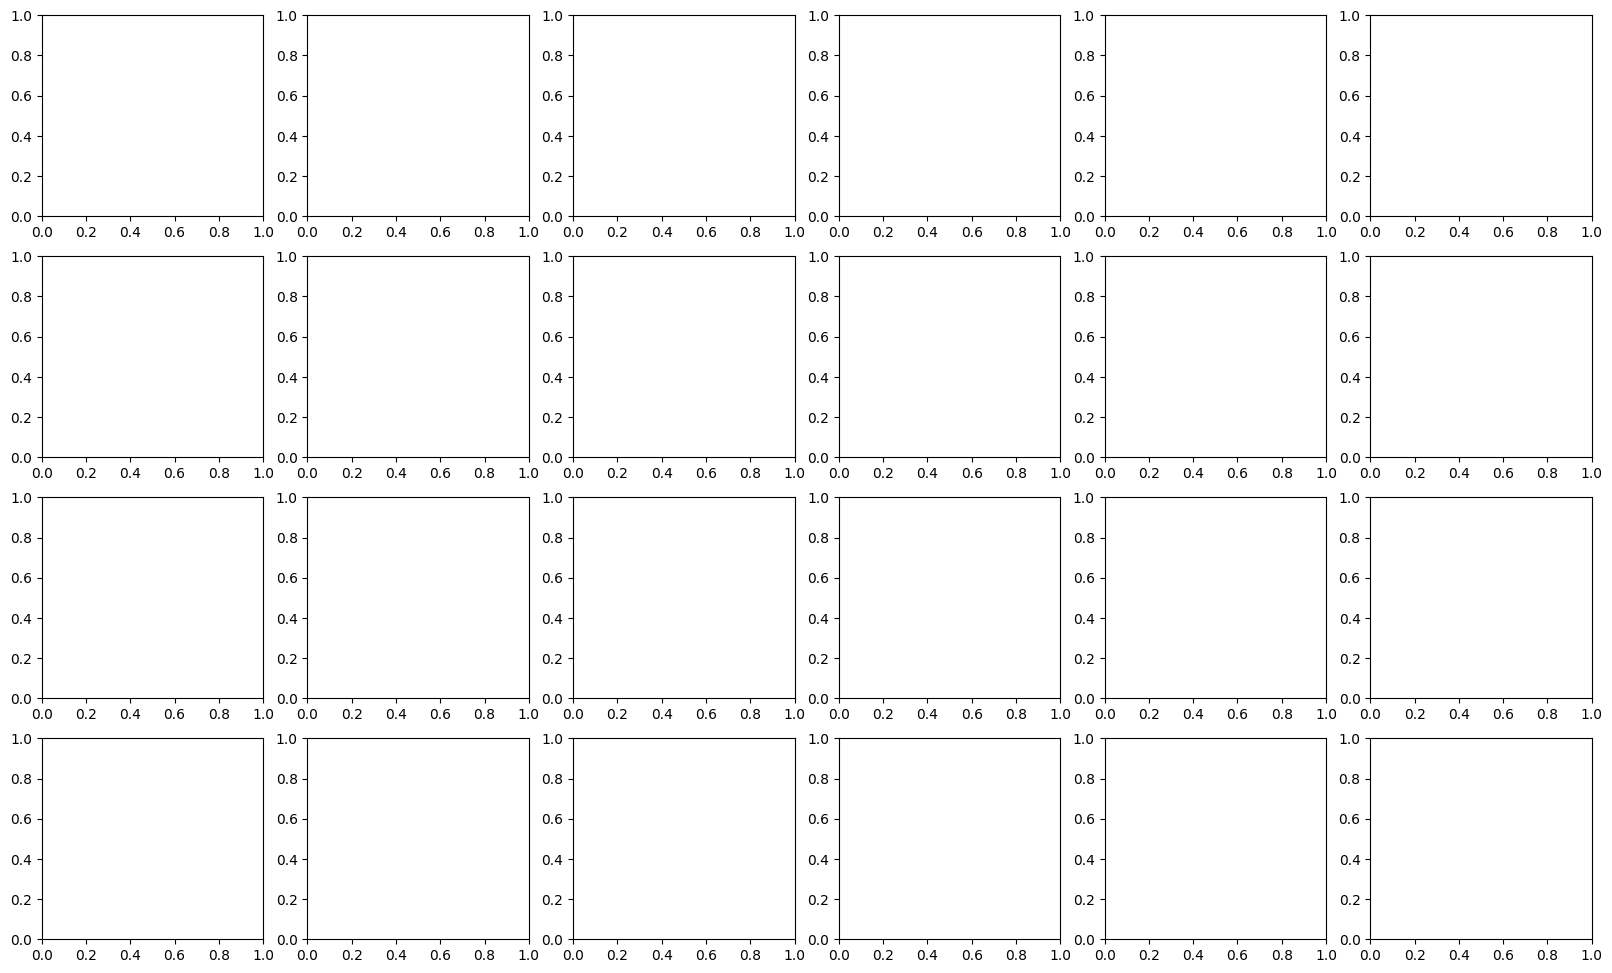

In [57]:
# ── Grad-CAM sur les prédictions correctes ──
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(20, 3 * NUM_CLASSES))

for i, cls in enumerate(CLASS_NAMES):
    for j in range(min(3, len(correct_examples[cls]))):
        img = correct_examples[cls][j]
        img_batch = np.expand_dims(img, 0)
        heatmap, pred_cls = make_gradcam_heatmap(best_model, img_batch, last_conv_info)
        overlay = overlay_gradcam(img, heatmap)

        # Image originale
        axes[i, 2*j].imshow(img.squeeze(), cmap='gray')
        axes[i, 2*j].axis('off')
        if j == 0:
            axes[i, 2*j].set_ylabel(cls, fontsize=11, fontweight='bold', rotation=0, labelpad=80)

        # Grad-CAM overlay
        axes[i, 2*j+1].imshow(overlay)
        axes[i, 2*j+1].axis('off')

plt.suptitle(f"Grad-CAM — Prédictions CORRECTES ({best_name}) — Original | Heatmap",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Grad-CAM sur les prédictions incorrectes ──
has_incorrect = any(len(v) > 0 for v in incorrect_examples.values())

if has_incorrect:
    classes_with_errors = [cls for cls in CLASS_NAMES if len(incorrect_examples[cls]) > 0]
    n_rows = len(classes_with_errors)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, 3 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for i, cls in enumerate(classes_with_errors):
        for j in range(3):
            if j < len(incorrect_examples[cls]):
                img, pred_name = incorrect_examples[cls][j]
                img_batch = np.expand_dims(img, 0)
                heatmap, _ = make_gradcam_heatmap(best_model, img_batch, last_conv_info)
                overlay = overlay_gradcam(img, heatmap)

                axes[i, j].imshow(overlay)
                axes[i, j].set_title(f"Prédit: {pred_name}", fontsize=9, color='red')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(cls, fontsize=11, fontweight='bold',
                                       rotation=0, labelpad=80)

    plt.suptitle(f"Grad-CAM — Prédictions INCORRECTES ({best_name})",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune prédiction incorrecte trouvée dans l'échantillon de test !")

## 10. Conclusion

### Résumé

| Modèle | Approche | Points clés |
|--------|----------|-------------|
| **Baseline CNN** | 4 blocs Conv + GAP + class_weight | Plancher de performance, entraîné from scratch |
| **EfficientNetV2B0** | Transfer Learning 2 phases + class_weight | Feature extraction → Fine-tuning, poids ImageNet |
| **DenseNet121** | Architecture CheXNet + Transfer Learning 2 phases | Connexions denses, poids ImageNet, preprocessing standard |

### Pourquoi DenseNet121 (CheXNet) ?
- **Architecture** : Les connexions denses propagent les features de toutes les couches, préservant les détails subtils des radiographies
- **Référence médicale** : CheXNet (Stanford, 2017) a démontré des performances au niveau de radiologues sur ChestX-ray14 avec cette même architecture
- **Preprocessing standard** : Normalisation ImageNet par canal (mean/std), plus stable que le preprocessing spécifique d'EfficientNet

### Corrections appliquées (v2 → v3)
- **`class_weight`** : pondération inversement proportionnelle à la fréquence de chaque classe
- **Conversion grayscale→RGB** : `tf.repeat` (réplication simple) pour les deux modèles TL
- **Preprocessing adapté** : rescaling + normalisation spécifique pour chaque backbone
- **Grad-CAM amélioré** : normalisation du contraste + affichage côte-à-côte original/heatmap

### Pistes d'amélioration restantes
- Charger les vrais poids CheXNet (PyTorch → Keras) pour un transfert encore plus pertinent
- Ensemble de modèles (voting/stacking des 3 modèles)
- Cross-validation pour des métriques plus robustes